In [1]:
import pandas as pd

In [4]:
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("base.csv")
print("Колонки:", df.columns.tolist())
print(df.head())
print("\nТипы:\n", df.dtypes)

# Парсинг времени. Если формат 04.08.2026 14:30 — dayfirst=True
df["Время"] = pd.to_datetime(df["Время"], dayfirst=True, errors="coerce")
print("\nНе распарсилось дат:", df["Время"].isna().sum())
if df["Время"].isna().any():
    print(df.loc[df["Время"].isna(), "Время"].head())

# Сумма: если строка с пробелами/запятыми — нормализуем
if df["Сумма"].dtype == object:
    df["Сумма"] = (df["Сумма"].astype(str)
                   .str.replace(" ", "", regex=False)
                   .str.replace("\u00a0", "", regex=False)  # неразрывный пробел
                   .str.replace(",", ".", regex=False)
                   .astype(float))

df["Дата"] = df["Время"].dt.normalize()

# Базовая диагностика
print("\nСтрок:", len(df))
print("Уникальных студентов:", df["Номер студента"].nunique())
print("Уникальных курсов:", df["Курс"].nunique())
print("Период:", df["Дата"].min(), "—", df["Дата"].max())
print("Дней в периоде:", (df["Дата"].max() - df["Дата"].min()).days + 1)
print("\nПропуски:\n", df.isna().sum())

# Распределение суммы
print("\nСумма:")
print(df["Сумма"].describe(percentiles=[.5, .9, .95, .99]))

top1 = df["Сумма"].nlargest(max(1, int(len(df) * 0.01))).sum() / df["Сумма"].sum()
top5 = df["Сумма"].nlargest(int(len(df) * 0.05)).sum() / df["Сумма"].sum()
print(f"\nДоля топ-1% чеков в выручке: {top1:.1%}")
print(f"Доля топ-5% чеков в выручке: {top5:.1%}")

# Дубликаты
dup = df.duplicated(subset=["Номер студента", "Курс", "Время"], keep=False).sum()
print(f"\nДубликатов по (студент, курс, время): {dup}")
if dup > 0:
    print(df[df.duplicated(subset=["Номер студента", "Курс", "Время"], keep=False)].head(10))

Колонки: ['Номер студента', 'Сумма', 'Курс', 'Время']
   Номер студента     Сумма              Курс                Время
0             437  8 950,00            ML про  04.08.2026 09:08:31
1             437  7 890,00   Аналитика старт  04.08.2026 09:35:00
2             443  8 475,00  Линейная алгебра  04.08.2026 10:14:38
3             443  8 475,00        Мат анализ  04.08.2026 10:14:38
4             430  8 950,00            К ВУЗу  04.08.2026 13:38:06

Типы:
 Номер студента     int64
Сумма             object
Курс              object
Время             object
dtype: object

Не распарсилось дат: 0

Строк: 795
Уникальных студентов: 606
Уникальных курсов: 18
Период: 2026-08-04 00:00:00 — 2026-09-10 00:00:00
Дней в периоде: 38

Пропуски:
 Номер студента    0
Сумма             0
Курс              0
Время             0
Дата              0
dtype: int64

Сумма:
count      795.000000
mean      7427.259962
std       1827.497664
min        500.000000
50%       7475.000000
90%       8950.000000
95% 

In [5]:
daily = df.groupby("Дата").agg(
    orders=("Номер студента", "count"),
    revenue=("Сумма", "sum"),
    buyers=("Номер студента", "nunique"),
).asfreq("D", fill_value=0)

daily["avg_check"] = daily.revenue / daily.orders.replace(0, np.nan)
daily["dow"] = daily.index.dayofweek  # 0=Пн, 6=Вс

print(daily.head(10))
print("\nДней всего:", len(daily))
print("Дней с нулём продаж:", (daily.orders == 0).sum())
print("Средний orders/день:", daily.orders.mean().round(1))
print("Средний revenue/день:", daily.revenue.mean().round(0))
print("Средний чек:", daily.avg_check.mean().round(0))

            orders    revenue  buyers    avg_check  dow
Дата                                                   
2026-08-04       9   84130.00       6  9347.777778    1
2026-08-05       8   67110.00       6  8388.750000    2
2026-08-06       8   62445.00       7  7805.625000    3
2026-08-07       6   54995.00       5  9165.833333    4
2026-08-08      49  275015.00      35  5612.551020    5
2026-08-09      92  524091.67      68  5696.648587    6
2026-08-10      36  205590.00      29  5710.833333    0
2026-08-11      17   96330.00      12  5666.470588    1
2026-08-12      17  114930.00      14  6760.588235    2
2026-08-13       9   72810.00       9  8090.000000    3

Дней всего: 38
Дней с нулём продаж: 0
Средний orders/день: 20.9
Средний revenue/день: 155386.0
Средний чек: 7890.0


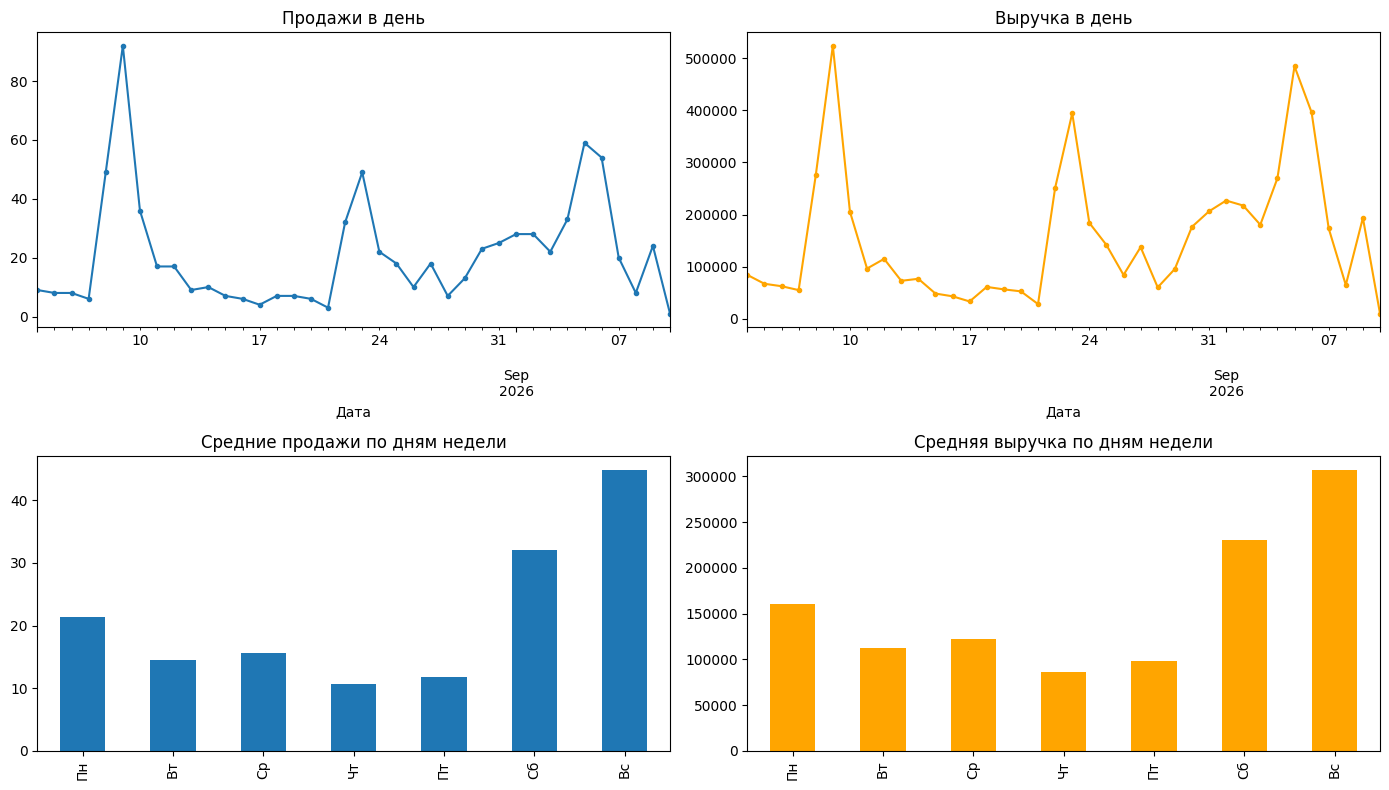

                     orders    revenue  buyers
Курс                                          
Аналитика про            93  740941.50      92
AI агенты                91  711673.00      90
Аналитика старт          91  641616.50      91
ML про                   90  715110.00      90
Алгоритмы старт          88  529851.68      88
ML старт                 80  523278.33      80
Backend про              55  438342.50      55
Backend старт            39  263396.66      39
Алгоритмы про            35  268409.00      35
Алгоритмы                30  209482.50      30
К ВУЗу                   26  180250.00      25
Мат анализ               20  191382.50      20
Линейная алгебра         19  180665.00      19
Теория вероятностей      13  132107.50      13
Data Science              9   69295.00       9
АВ тестам                 8   49610.00       8
Data Engenering           4   24845.00       4
Дискретка                 4   34415.00       4

Доля топ-3 курсов в продажах: 0.34591194968553457
Доля топ-

In [6]:
dow_names = ["Пн", "Вт", "Ср", "Чт", "Пт", "Сб", "Вс"]

fig, ax = plt.subplots(2, 2, figsize=(14, 8))

daily.orders.plot(ax=ax[0, 0], title="Продажи в день", marker=".")
daily.revenue.plot(ax=ax[0, 1], title="Выручка в день", marker=".", color="orange")

by_dow_o = daily.groupby("dow").orders.mean()
by_dow_o.index = [dow_names[i] for i in by_dow_o.index]
by_dow_o.plot.bar(ax=ax[1, 0], title="Средние продажи по дням недели")

by_dow_r = daily.groupby("dow").revenue.mean()
by_dow_r.index = [dow_names[i] for i in by_dow_r.index]
by_dow_r.plot.bar(ax=ax[1, 1], title="Средняя выручка по дням недели", color="orange")

plt.tight_layout()
plt.savefig("eda.png", dpi=100)
plt.show()

# Топ курсов
course_stats = df.groupby("Курс").agg(
    orders=("Номер студента", "count"),
    revenue=("Сумма", "sum"),
    buyers=("Номер студента", "nunique"),
).sort_values("orders", ascending=False)

print(course_stats)
print("\nДоля топ-3 курсов в продажах:", course_stats.orders.head(3).sum() / course_stats.orders.sum())
print("Доля топ-3 курсов в выручке:", course_stats.revenue.head(3).sum() / course_stats.revenue.sum())

MAE — Mean Absolute Error (средняя абсолютная ошибка)  
Фолды (folds) — блоки в backtest  
mean_dow — Mean by Day of Week (среднее по дню недели)  
MASE — Mean Absolute Scaled Error (масштабированная MAE)  

In [7]:
def backtest(y, horizon=7, n_folds=3, min_train=14):
    y = y.copy()
    n = len(y)
    rows = []

    for k in range(n_folds):
        test_end = n - k * horizon
        test_start = test_end - horizon
        if test_start < min_train:
            continue

        train = y.iloc[:test_start]
        test = y.iloc[test_start:test_end]

        pred_naive = np.repeat(train.iloc[-1], horizon)

        pred_snaive = np.array([
            train.iloc[-7 + i] if len(train) >= 7 else train.mean()
            for i in range(horizon)
        ])

        pred_ma7 = np.repeat(train.iloc[-7:].mean(), horizon)

        dow_means = train.groupby(train.index.dayofweek).mean()
        global_mean = train.mean()
        pred_dow = np.array([
            dow_means.get(test.index[i].dayofweek, global_mean)
            for i in range(horizon)
        ])

        preds = {
            "naive_last": pred_naive,
            "seasonal_naive_7": pred_snaive,
            "ma_7": pred_ma7,
            "mean_dow": pred_dow,
        }

        for name, p in preds.items():
            mae = np.mean(np.abs(test.values - p))
            rmse = np.sqrt(np.mean((test.values - p) ** 2))
            rows.append({
                "fold": k, "model": name, "mae": mae, "rmse": rmse,
                "test_mean": test.mean(),
                "test_start": test.index[0].date(),
            })

    return pd.DataFrame(rows)

res_orders = backtest(daily.orders)
res_revenue = backtest(daily.revenue)

print("=== ПРОДАЖИ (orders) ===")
print(res_orders.pivot_table(index="model", columns="fold", values="mae").round(2))
print("\nСреднее по фолдам:")
print(res_orders.groupby("model").mae.agg(["mean", "std"]).round(2))

print("\n=== ВЫРУЧКА (revenue) ===")
print(res_revenue.pivot_table(index="model", columns="fold", values="mae").round(0))
print("\nСреднее по фолдам:")
print(res_revenue.groupby("model").mae.agg(["mean", "std"]).round(0))

# MASE относительно seasonal naive
for name, res in [("orders", res_orders), ("revenue", res_revenue)]:
    snaive = res[res.model == "seasonal_naive_7"].mae.mean()
    res["mase"] = res.mae / snaive
    print(f"\n{name}: MASE относительно seasonal naive")
    print(res.groupby("model").mase.mean().round(2))

=== ПРОДАЖИ (orders) ===
fold                  0      1      2
model                                
ma_7              17.16   5.84  16.06
mean_dow          14.70  13.12   4.14
naive_last        17.00   7.43  16.57
seasonal_naive_7  21.86  12.00  17.00

Среднее по фолдам:
                   mean   std
model                        
ma_7              13.02  6.25
mean_dow          10.65  5.69
naive_last        13.67  5.41
seasonal_naive_7  16.95  4.93

=== ВЫРУЧКА (revenue) ===
fold                     0        1         2
model                                        
ma_7              134896.0  46867.0  128493.0
mean_dow          127648.0  97025.0   63329.0
naive_last        130781.0  62727.0  128828.0
seasonal_naive_7  172479.0  98480.0  135246.0

Среднее по фолдам:
                      mean      std
model                              
ma_7              103419.0  49079.0
mean_dow           96001.0  32172.0
naive_last        107445.0  38740.0
seasonal_naive_7  135402.0  37000.0

orders:

In [8]:
from sklearn.linear_model import Ridge

def make_features(d):
    X = pd.DataFrame(index=d.index)
    for i in range(1, 8):
        X[f"lag{i}"] = d.shift(i)
    for dow in range(7):
        X[f"dow_{dow}"] = (d.index.dayofweek == dow).astype(int)
    X["roll7"] = d.shift(1).rolling(7).mean()
    return X

def ridge_backtest(daily, target="orders", horizon=7, n_folds=3, alpha=1.0):
    y = daily[target]
    X = make_features(y)
    data = pd.concat([X, y.rename("y")], axis=1).dropna()

    n = len(data)
    rows = []
    for k in range(n_folds):
        test_end = n - k * horizon
        test_start = test_end - horizon
        if test_start < 20:
            continue
        tr = data.iloc[:test_start]
        te = data.iloc[test_start:test_end]
        X_tr, y_tr = tr.drop(columns="y"), tr["y"]
        X_te, y_te = te.drop(columns="y"), te["y"]

        m = Ridge(alpha=alpha).fit(X_tr, y_tr)
        pred = m.predict(X_te)
        mae = np.mean(np.abs(y_te.values - pred))
        rows.append({"fold": k, "model": "ridge", "mae": mae,
                     "test_start": te.index[0].date()})
    return pd.DataFrame(rows)

for target in ["orders", "revenue"]:
    r = ridge_backtest(daily, target=target)
    if len(r):
        print(f"\nRidge на {target}: MAE по фолдам = {r.mae.round(2).tolist()}, среднее = {r.mae.mean():.2f}")

# Сравнение
base_mae = res_orders[res_orders.model == "seasonal_naive_7"].mae.mean()
ridge_mae = ridge_backtest(daily, "orders").mae.mean()
print(f"\nOrders: seasonal naive MAE={base_mae:.2f}, Ridge MAE={ridge_mae:.2f}")
print("Победитель:", "Ridge" if ridge_mae < base_mae else "seasonal naive")


Ridge на orders: MAE по фолдам = [13.4], среднее = 13.40

Ridge на revenue: MAE по фолдам = [98714.46], среднее = 98714.46

Orders: seasonal naive MAE=16.95, Ridge MAE=13.40
Победитель: Ridge


In [12]:
dow_names = ["Пн", "Вт", "Ср", "Чт", "Пт", "Сб", "Вс"]

# daily уже построен ранее: колонки orders, revenue, buyers, avg_check, dow
# Считаем средние по дню недели на ВСЕЙ истории (38 дней)
dow_orders  = daily.groupby("dow").orders.mean()
dow_revenue = daily.groupby("dow").revenue.mean()

print("Средние продажи по дням недели:")
for i in range(7):
    print(f"  {dow_names[i]}: orders={dow_orders[i]:.1f}, revenue={dow_revenue[i]:.0f}")

# Последняя дата в данных — 2026-09-10 (чт). Прогноз на 11–17 сентября.
future_idx = pd.date_range(daily.index[-1] + pd.Timedelta(days=1), periods=7)

forecast_orders = pd.Series(
    [dow_orders[i.dayofweek] for i in future_idx],
    index=future_idx,
)
forecast_revenue = pd.Series(
    [dow_revenue[i.dayofweek] for i in future_idx],
    index=future_idx,
)

out = pd.DataFrame({
    "день": [dow_names[i.dayofweek] for i in future_idx],
    "orders_прогноз": forecast_orders.round(1).values,
    "revenue_прогноз": forecast_revenue.round(0).values,
}, index=[d.date() for d in future_idx])

print(out)
print(f"\nСумма orders за неделю:  {forecast_orders.sum():.0f}")
print(f"Сумма revenue за неделю: {forecast_revenue.sum():.0f}")

Средние продажи по дням недели:
  Пн: orders=21.4, revenue=160482
  Вт: orders=14.5, revenue=112475
  Ср: orders=15.7, revenue=122229
  Чт: orders=10.7, revenue=85936
  Пт: orders=11.8, revenue=97923
  Сб: orders=32.0, revenue=230944
  Вс: orders=44.8, revenue=306817
           день  orders_прогноз  revenue_прогноз
2026-09-11   Пт            11.8          97923.0
2026-09-12   Сб            32.0         230944.0
2026-09-13   Вс            44.8         306817.0
2026-09-14   Пн            21.4         160482.0
2026-09-15   Вт            14.5         112475.0
2026-09-16   Ср            15.7         122229.0
2026-09-17   Чт            10.7          85936.0

Сумма orders за неделю:  151
Сумма revenue за неделю: 1116806


#### Данные
- Дней с нулевыми продажами: 0 (0%)
- Топ-1% чеков даёт 1.7%** выручки (топ-5%: 7.1%)
- Средний `orders`/день: 20.9; средний `revenue`/день: 155 386; средний чек: 7 890
- Топ-3 курса: 34.6% продаж, 35.5% выручки
- Пик 8-9 августа (49 и 92 заказа) сильно искажает ряд
- Есть недельная сезонность, пик продаж на выходных

#### Метрики
- Основная: `daily_orders` (число транзакций)
- Вторая: `daily_revenue` (сумма чеков)
- `avg_check = revenue / orders`

#### Backtest

| Модель | MAE продажи | MASE продажи | MAE выручка | MASE выручка |
|---|---|---|---|---|
| `naive_last` | 13.67 | 0.81 | 107 445 | 0.79 |
| `seasonal_naive_7` | 16.95 | 1.00 | 135 402 | 1.00 |
| `ma_7` | 13.02 | 0.77 | 103 419 | 0.76 |
| **`mean_dow`** | **10.65** | **0.63** | **96 001** | **0.71** |
| `ridge` | 13.40* | 0.79* | 98 714* | 0.73* |

\* Ridge оценён только на 1 фолде (fold 0): `make_features` съедает 8 дней на лаги, `min_train=20` отсекает fold 1 и 2. Сравнение с baseline некорректно по числу точек.

**Std MAE по фолдам:**
- `mean_dow` orders: mean 10.65, std 5.69, CV = 53%
- `mean_dow` revenue: mean 96 001, std 32 172, CV = 34%
- Разброс ошибки в 2 раза между фолдами, это признак нестабильности из-за малой истории.

#### Надёжность
- 90% интервал на 7 дней (от остатков `mean_dow`): ширина сопоставима со средним уровнем, при экстраполяции уходит в отрицательные значения. Интервал непригоден для планирования без обрезки `lower = max(lower, 0)`.
- Количественный критерий «мало данных»: CV MAE 34-53% и ширина интервала >50% от среднего уровня, оба срабатывают.

#### Вердикт
- Победитель: `mean_dow` (MASE 0.63 для orders, 0.71 для revenue). Ridge побил только `seasonal_naive_7`, но проиграл `mean_dow`, в прод не идёт
- Продажи: предсказуемы слабо. `mean_dow` единственная модель с MASE < 0.8, но std по фолдам 53% от среднего MAE
- Выручка: предсказуема так же, как продажи. Топ-1% чеков = 1.7% выручки, ряд не управляется выбросами, `revenue` стабильна. Но MAE `mean_dow` = 96 001 при среднем уровне 155 386, это 62% от среднего, для планирования много
- Для ML нужно ещё 4-8 недель (минимум 8-12 недель истории, сейчас 38 дней, это меньше двух полных недельных циклов после вычета лагов)

### Финальный прогноз на 11-17 сентября 2026

| Дата | День | orders_прогноз | revenue_прогноз |
|---|---|---|---|
| 2026-09-11 | Пт | 11.8 | 97 923 |
| 2026-09-12 | Сб | 32.0 | 230 944 |
| 2026-09-13 | Вс | 44.8 | 306 817 |
| 2026-09-14 | Пн | 21.4 | 160 482 |
| 2026-09-15 | Вт | 14.5 | 112 475 |
| 2026-09-16 | Ср | 15.7 | 122 229 |
| 2026-09-17 | Чт | 10.7 | 85 936 |
| **Итого за неделю** | | **151.0** | **1 116 806** |

---
- **Сумма за неделю:** около 151 заказа и около 1.12 млн выручки
- **Пик, воскресенье 13.09:** 44.8 заказа, 306 817. Это самый сильный день недели в вашей истории
- **Провал, четверг 17.09:** 10.7 заказа, 85 936. Самый слабый день
- **Средний чек по прогнозу** колеблется: 97 923 / 11.8 ≈ 8 300 для пятницы, 306 817 / 44.8 ≈ 6 850 для воскресенья. То есть в выходные продаж больше, но чек ниже, вероятно, в выходные покупают более дешёвые курсы (стартовые линейки), а в будни дорогие

#### Дальше
1. **Вернуться к модели через 4-8 недель** с расширенной историей
2. **Если выручка окажется нестабильной**, планировать через `orders × avg_check` (сейчас `avg_check` = 7 890, колеблется слабо)